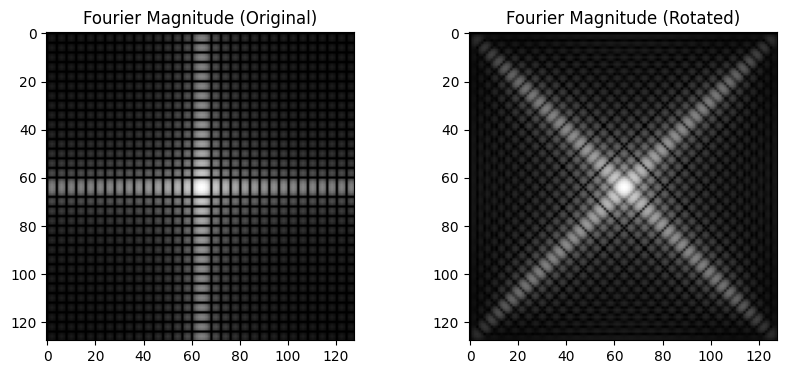

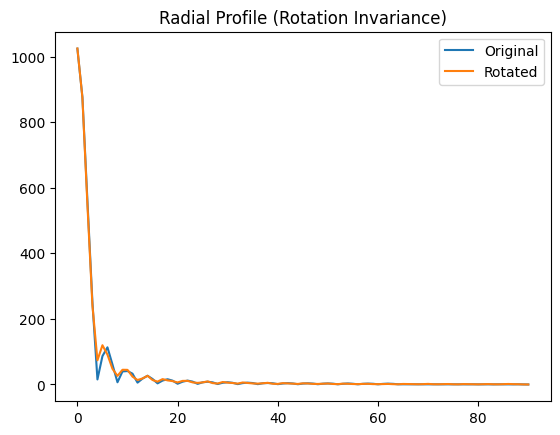

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate

# Generate a simple image
image = np.zeros((128, 128))
image[48:80, 48:80] = 1  # A square at the center

# Rotate the image
rotated_image = rotate(image, angle=45, reshape=False)

# Compute the Fourier Transform
fft_image = np.fft.fftshift(np.fft.fft2(image))
fft_rotated = np.fft.fftshift(np.fft.fft2(rotated_image))

# Compute Fourier magnitude
magnitude_image = np.abs(fft_image)
magnitude_rotated = np.abs(fft_rotated)

# Compute radial profile
def radial_profile(magnitude):
    center = np.array(magnitude.shape) // 2
    y, x = np.indices(magnitude.shape)
    radius = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    radius = radius.astype(int)  # Use int instead of np.int

    radial_sum = np.bincount(radius.ravel(), magnitude.ravel())
    radial_count = np.bincount(radius.ravel())
    radial_average = radial_sum / (radial_count + 1e-8)  # Avoid division by zero

    return radial_average

radial_profile_image = radial_profile(magnitude_image)
radial_profile_rotated = radial_profile(magnitude_rotated)

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(121)
plt.imshow(np.log1p(magnitude_image), cmap='gray')
plt.title("Fourier Magnitude (Original)")
plt.subplot(122)
plt.imshow(np.log1p(magnitude_rotated), cmap='gray')
plt.title("Fourier Magnitude (Rotated)")
plt.figure()
plt.plot(radial_profile_image, label='Original')
plt.plot(radial_profile_rotated, label='Rotated')
plt.legend()
plt.title("Radial Profile (Rotation Invariance)")
plt.show()


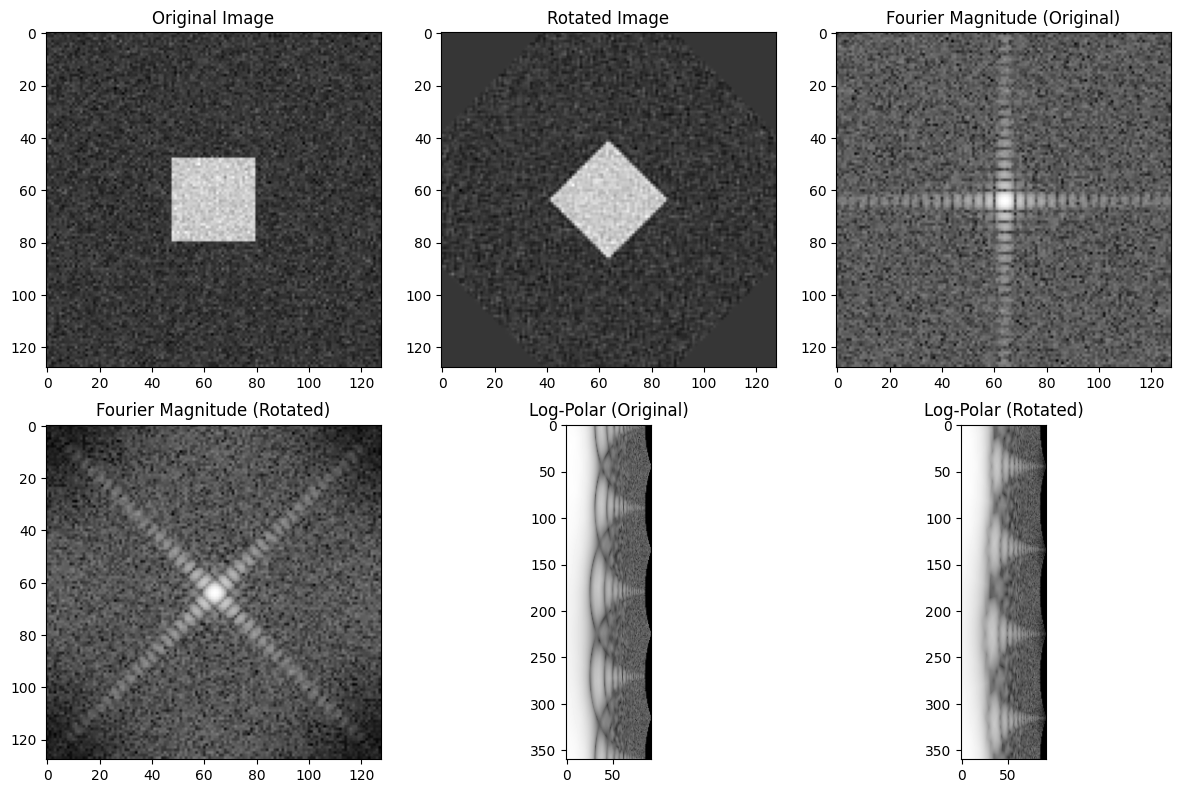

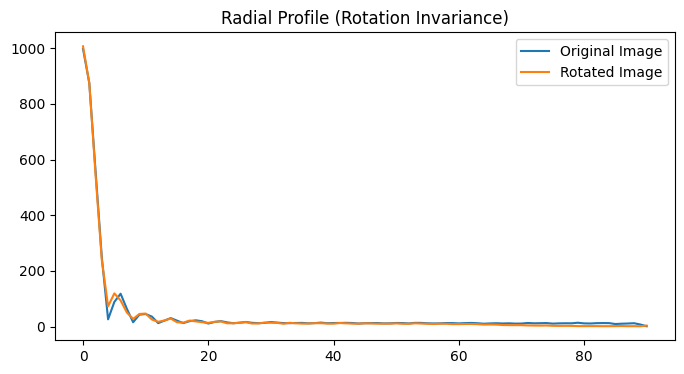

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from skimage.transform import warp_polar

# Helper function to compute the radial profile
def radial_profile(magnitude):
    center = np.array(magnitude.shape) // 2
    y, x = np.indices(magnitude.shape)
    radius = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    radius = radius.astype(int)
    radial_sum = np.bincount(radius.ravel(), magnitude.ravel())
    radial_count = np.bincount(radius.ravel())
    radial_average = radial_sum / (radial_count + 1e-8)  # Avoid division by zero
    return radial_average

# Create a sample image with noise
image = np.zeros((128, 128))
image[48:80, 48:80] = 1  # Square at the center
image = image + np.random.normal(scale=0.1, size=image.shape)  # Add noise

# Rotate the image
rotated_image = rotate(image, angle=45, reshape=False)

# Compute Fourier Transform
fft_image = np.fft.fftshift(np.fft.fft2(image))
fft_rotated = np.fft.fftshift(np.fft.fft2(rotated_image))

# Compute Fourier magnitude
magnitude_image = np.abs(fft_image)
magnitude_rotated = np.abs(fft_rotated)

# Apply log-polar transformation to Fourier magnitude
log_polar_image = warp_polar(magnitude_image, scaling='log')
log_polar_rotated = warp_polar(magnitude_rotated, scaling='log')

# Compute radial profiles
radial_profile_image = radial_profile(magnitude_image)
radial_profile_rotated = radial_profile(magnitude_rotated)

# Plot results
plt.figure(figsize=(12, 8))

# Original and rotated images
plt.subplot(231)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.subplot(232)
plt.imshow(rotated_image, cmap='gray')
plt.title("Rotated Image")

# Fourier magnitudes
plt.subplot(233)
plt.imshow(np.log1p(magnitude_image), cmap='gray')
plt.title("Fourier Magnitude (Original)")
plt.subplot(234)
plt.imshow(np.log1p(magnitude_rotated), cmap='gray')
plt.title("Fourier Magnitude (Rotated)")

# Log-polar transformed magnitudes
plt.subplot(235)
plt.imshow(np.log1p(log_polar_image), cmap='gray')
plt.title("Log-Polar (Original)")
plt.subplot(236)
plt.imshow(np.log1p(log_polar_rotated), cmap='gray')
plt.title("Log-Polar (Rotated)")

plt.tight_layout()
plt.show()

# Plot radial profiles
plt.figure(figsize=(8, 4))
plt.plot(radial_profile_image, label='Original Image')
plt.plot(radial_profile_rotated, label='Rotated Image')
plt.title("Radial Profile (Rotation Invariance)")
plt.legend()
plt.show()



In [ ]:
!pip install mahotas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 79.3 MB/s eta 0:00:00


Zernike Moments (Original): [3.18309886e-01 2.32632044e-07 1.85912838e-03 3.05809388e-05
 2.44762950e-06 1.35123785e-06 2.92029490e-03 1.10731489e-04
 1.82903616e-05 9.61969049e-06 4.77729628e-06 6.97474888e-07
 3.90367484e-03 1.78818318e-04 5.57302806e-05 3.05700288e-06
 1.30478995e-05 6.05167369e-06 3.75353409e-06 2.68962246e-07
 5.25198270e-03 1.46065592e-04 1.36672882e-04 2.09811505e-05
 5.36184795e-04]
Zernike Moments (Rotated): [3.18309886e-01 2.57676928e-06 1.77185664e-03 1.56445085e-11
 5.18222549e-06 2.62491820e-16 2.92420632e-03 7.85128704e-11
 1.22665981e-05 7.84435398e-06 2.97899542e-10 2.97900144e-10
 4.03202972e-03 2.21041041e-10 1.05323840e-06 4.22541665e-15
 1.05896983e-05 3.63092319e-10 3.63095758e-10 1.36954104e-16
 5.07521357e-03 4.77070989e-10 3.39618794e-05 1.20352123e-14
 5.35417973e-04]


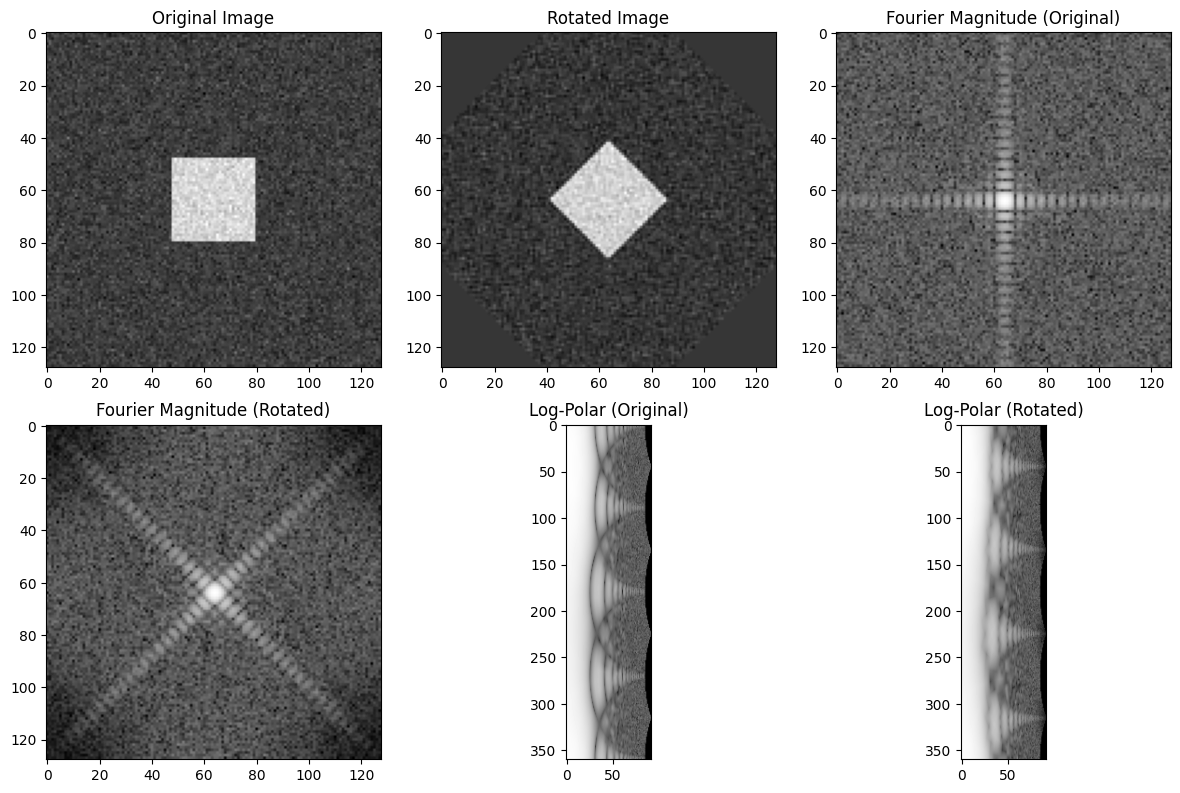

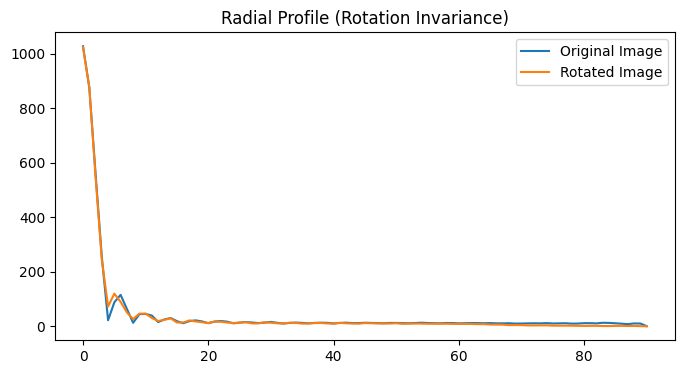

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from skimage.transform import warp_polar
import mahotas  # Import mahotas for Zernike moments

# Helper function to compute the radial profile
def radial_profile(magnitude):
    center = np.array(magnitude.shape) // 2
    y, x = np.indices(magnitude.shape)
    radius = np.sqrt((x - center[1])**2 + (y - center[0])**2)
    radius = radius.astype(int)
    radial_sum = np.bincount(radius.ravel(), magnitude.ravel())
    radial_count = np.bincount(radius.ravel())
    radial_average = radial_sum / (radial_count + 1e-8)  # Avoid division by zero
    return radial_average

# Create a sample image with noise
image = np.zeros((128, 128))
image[48:80, 48:80] = 1  # Square at the center
image = image + np.random.normal(scale=0.1, size=image.shape)  # Add noise

# Rotate the image
rotated_image = rotate(image, angle=45, reshape=False)

# Compute Fourier Transform
fft_image = np.fft.fftshift(np.fft.fft2(image))
fft_rotated = np.fft.fftshift(np.fft.fft2(rotated_image))

# Compute Fourier magnitude
magnitude_image = np.abs(fft_image)
magnitude_rotated = np.abs(fft_rotated)

# Apply log-polar transformation to Fourier magnitude
log_polar_image = warp_polar(magnitude_image, scaling='log')
log_polar_rotated = warp_polar(magnitude_rotated, scaling='log')

# Compute radial profiles
radial_profile_image = radial_profile(magnitude_image)
radial_profile_rotated = radial_profile(magnitude_rotated)

# Compute Zernike moments using mahotas
radius = 64  # Radius for Zernike moments
thresh_image = (magnitude_image > 0.1).astype(np.uint8)  # Threshold for binary image
thresh_rotated = (magnitude_rotated > 0.1).astype(np.uint8)

zernike_original = mahotas.features.zernike_moments(thresh_image, radius=radius, degree=8)
zernike_rotated = mahotas.features.zernike_moments(thresh_rotated, radius=radius, degree=8)

print("Zernike Moments (Original):", zernike_original)
print("Zernike Moments (Rotated):", zernike_rotated)

# Plot results
plt.figure(figsize=(12, 8))

# Original and rotated images
plt.subplot(231)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.subplot(232)
plt.imshow(rotated_image, cmap='gray')
plt.title("Rotated Image")

# Fourier magnitudes
plt.subplot(233)
plt.imshow(np.log1p(magnitude_image), cmap='gray')
plt.title("Fourier Magnitude (Original)")
plt.subplot(234)
plt.imshow(np.log1p(magnitude_rotated), cmap='gray')
plt.title("Fourier Magnitude (Rotated)")



# Save the plot as an image
plt.savefig("plot_image-1.png", format='png', dpi=300)


# Log-polar transformed magnitudes
plt.subplot(235)
plt.imshow(np.log1p(log_polar_image), cmap='gray')
plt.title("Log-Polar (Original)")
plt.subplot(236)
plt.imshow(np.log1p(log_polar_rotated), cmap='gray')
plt.title("Log-Polar (Rotated)")

plt.tight_layout()
# Save the plot as an image
plt.savefig("plot_image-2.png", format='png', dpi=300)
plt.show()

# Plot radial profiles
plt.figure(figsize=(8, 4))
plt.plot(radial_profile_image, label='Original Image')
plt.plot(radial_profile_rotated, label='Rotated Image')
plt.title("Radial Profile (Rotation Invariance)")
plt.legend()
# Save the plot as an image
plt.savefig("plot_image-3.png", format='png', dpi=300)

plt.show()



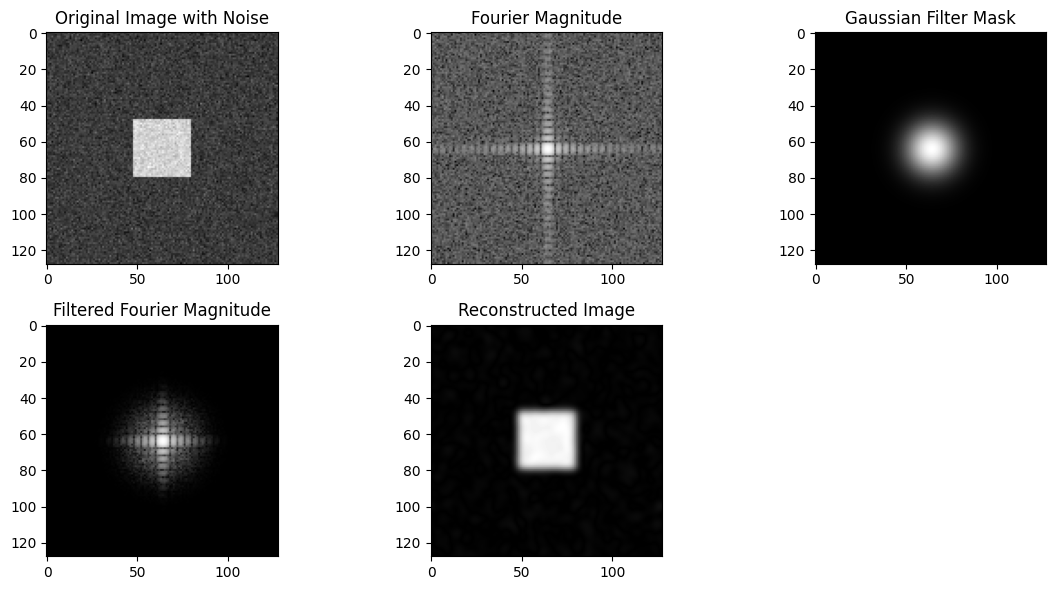

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.ndimage import rotate

# Create a sample image with noise
image = np.zeros((128, 128))
image[48:80, 48:80] = 1  # Square in the center
image = image + np.random.normal(scale=0.1, size=image.shape)  # Add noise

# Compute Fourier Transform
fft_image = np.fft.fftshift(np.fft.fft2(image))
magnitude_image = np.abs(fft_image)

# Create a Gaussian filter
def gaussian_filter_2d(shape, sigma):
    center = np.array(shape) // 2
    y, x = np.indices(shape)
    radius_squared = (x - center[1])**2 + (y - center[0])**2
    return np.exp(-radius_squared / (2 * sigma**2))

# Apply Gaussian filter to Fourier magnitude
sigma = 10  # Standard deviation of the Gaussian filter
gaussian_filter_mask = gaussian_filter_2d(magnitude_image.shape, sigma)
filtered_fft = fft_image * gaussian_filter_mask

# Inverse Fourier Transform to reconstruct the filtered image
filtered_image = np.fft.ifft2(np.fft.ifftshift(filtered_fft))
filtered_image_real = np.abs(filtered_image)

# Plot the original, Fourier magnitude, and filtered images
plt.figure(figsize=(12, 6))
plt.subplot(231)
plt.title("Original Image with Noise")
plt.imshow(image, cmap='gray')
plt.subplot(232)
plt.title("Fourier Magnitude")
plt.imshow(np.log1p(magnitude_image), cmap='gray')
plt.subplot(233)
plt.title("Gaussian Filter Mask")
plt.imshow(gaussian_filter_mask, cmap='gray')
plt.subplot(234)
plt.title("Filtered Fourier Magnitude")
plt.imshow(np.log1p(np.abs(filtered_fft)), cmap='gray')
plt.subplot(235)
plt.title("Reconstructed Image")
plt.imshow(filtered_image_real, cmap='gray')
plt.tight_layout()

# Save the plot as an image
plt.savefig("plot_image-4.png", format='png', dpi=300)
plt.show()
